# ЯндексКниги. Проверка гипотезы и составление аналитической записки

**Контекст**: вы работаете аналитиком данных и решили проверить гипотезу об активности пользователей, сравнив аудиторию в Санкт-Петербурге и Москве. Датасет, используемый в работе, был предварительно загружен из базы данных с помощью SQL.


- Автор: Каримов Газиз
- Дата: 15.09.2026

## Цели и задачи проекта

**Цель:** с помощью A/B-теста проверить гипотезу: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы

## Описание данных

Для работы предоставлен датасет с активностью пользователей в Москве и Санкт-Петербурге:`/datasets/yandex_knigi_data.csv`

Содержимое датасета:
 - `city` - город
 - `puid` - идентификатор пользователя
 - `hours` - длительность чтения или прослушивания в часах

## Содержимое проекта

1. Загрузка и знакомство с данными
2. Предобработка данных
3. Сравнение выборок
4. Проверка гипотезы
5. Выводы

## Загрузка данных и знакомство с ними

Загрузите данные пользователей из Москвы и Санкт-Петербурга c их активностью (суммой часов чтения и прослушивания) из файла `/datasets/yandex_knigi_data.csv`.

In [1]:
# Импортируем библиотеки
import pandas as pd

import matplotlib.pyplot as plt

from scipy import stats as st

from scipy.stats import ttest_ind

In [2]:
# Загружаем датасет
books_df = pd.read_csv('..\..\Data (csv)\Файлы. Яндекс книги\yandex_knigi_data.csv')

In [3]:
# Посмотрим на первые строки датасета
books_df.head()

,Unnamed: 0,city,puid,hours
0,0,Москва,9668,26.167776
1,1,Москва,16598,82.111217
2,2,Москва,80401,4.656906
3,3,Москва,140205,1.840556
4,4,Москва,248755,151.326434


In [4]:
# Выведем общую информацию о датасете
books_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8784 entries, 0 to 8783
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  8784 non-null   int64  
 1   city        8784 non-null   object 
 2   puid        8784 non-null   int64  
 3   hours       8784 non-null   float64
dtypes: float64(1), int64(2), object(1)
memory usage: 274.6+ KB


Итак, содержимое датасета соответствует описанию. Датасет содержит 8784 строк и 4 столбца. Пропусков в данных нет. Данные переведены к корректным типам. Один из столбцов без названия и, скорее всего, представляет собой индекс, продублированный в виде столбца - его можно убрать.

In [5]:
# Удалим безымянный столбец
books_df = books_df.drop('Unnamed: 0',axis=1)
books_df.head()

,city,puid,hours
0,Москва,9668,26.167776
1,Москва,16598,82.111217
2,Москва,80401,4.656906
3,Москва,140205,1.840556
4,Москва,248755,151.326434


## Предобработка данных

Проверим данные на полные дубликаты

In [6]:
books_df.duplicated().sum()

np.int64(0)

Проверим наличие дубликатов в поле *puid*

In [7]:
books_df.puid.duplicated().sum()

np.int64(244)

244 дубликата. Поскольку на этапе выгрузки данных из базы с помощью SQL выполнялась агрегация по городу и пользователю, наличие продублированных id пользователей говорит о том, выборки Санкт-Петербург и Москва имеют пересечение, что нельзя допускать при проведении A/B-теста. Удалим эти дубликаты.

In [8]:
books_df.drop_duplicates(subset='puid',inplace=True,keep=False)
books_df.puid.duplicated().sum()

np.int64(0)

## Сравнение выборок

### Оценим размеры выборок

In [9]:
msk = len(books_df[books_df['city']=='Москва'])
spb = len(books_df[books_df['city']=='Санкт-Петербург'])

ratio = round(msk/spb,2)

display(f'Число пользователей в Москве: {msk}, число пользователей в Санкт-Петербурге: {spb}, их отношение: {ratio}')

'Число пользователей в Москве: 5990, число пользователей в Санкт-Петербурге: 2306, их отношение: 2.6'

Итак, пользователей в Москве почти в 3 раза больше, чем в СПб.

### Выведем статистику по каждой выборке

In [10]:
msk_group = books_df[books_df['city']=='Москва']
spb_group = books_df[books_df['city']=='Санкт-Петербург']

In [11]:
msk_group['hours'].describe()

count    5990.000000
mean       10.848192
std        36.925622
min         0.000022
25%         0.057042
50%         0.888232
75%         5.933439
max       857.209373
Name: hours, dtype: float64

In [12]:
spb_group['hours'].describe()

count    2306.000000
mean       11.264433
std        39.831755
min         0.000025
25%         0.060173
50%         0.875355
75%         6.138424
max       978.764775
Name: hours, dtype: float64

Видно, что в данных присутствуют аномалии - максимальные значения в каждой выборке слишком большие. Избавимся от них, отфильтровав по 99 процентилю.

In [13]:
msk_group=msk_group[msk_group['hours']<msk_group['hours'].quantile(0.99)]
spb_group=spb_group[spb_group['hours']<spb_group['hours'].quantile(0.99)]

In [14]:
#  Проверим изменения в статистике
msk_group['hours'].describe()

count    5930.000000
mean        8.089568
std        19.823062
min         0.000022
25%         0.055508
50%         0.857040
75%         5.640947
max       153.966600
Name: hours, dtype: float64

In [15]:
spb_group['hours'].describe()

count    2282.000000
mean        8.254132
std        19.283430
min         0.000025
25%         0.056368
50%         0.851330
75%         5.647345
max       146.610567
Name: hours, dtype: float64

### Сравним распределения в выборках

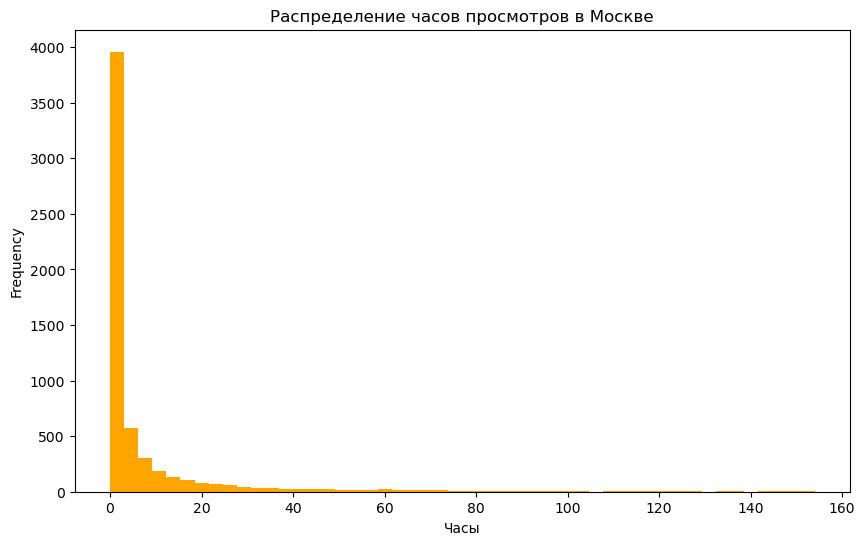

In [16]:
# Построим распределение для Московских пользователей
plt.figure(figsize=(10,6))

msk_group['hours'].plot(kind='hist',bins = 50,
                       color='orange')

plt.xlabel('Часы')
plt.title('Распределение часов просмотров в Москве')

plt.show()

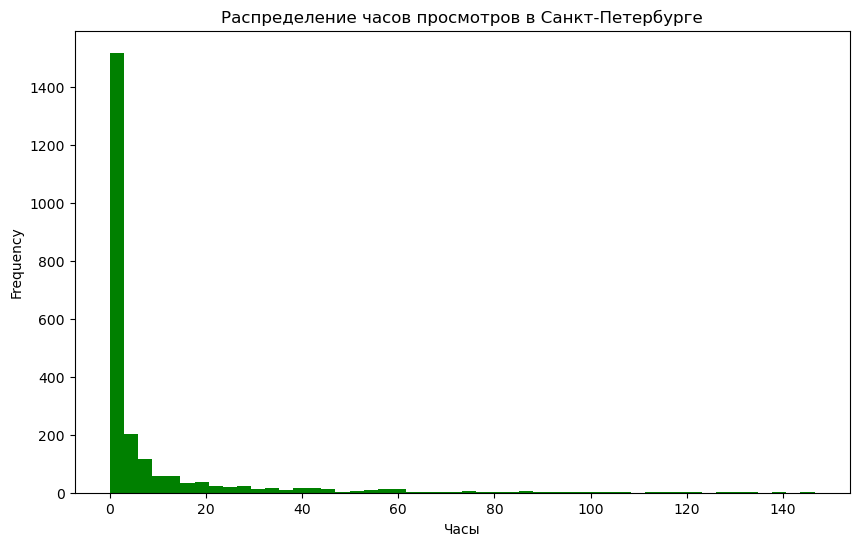

In [17]:
plt.figure(figsize=(10,6))

spb_group['hours'].plot(kind='hist',bins = 50,
                       color='green')

plt.xlabel('Часы')
plt.title('Распределение часов просмотров в Санкт-Петербурге')

plt.show()

Анализ статистики показал следующее:
 - выборки имеют расхождение в стандартной ошибке почти на 1.5 ед.
 - средние значения примерно равные (разница около 0.5)
 - распределения часов активности пользователей очень схожи

Поскольку есть различие в стандартных отклонениях, а следовательно и в дисперсиях, при проверке гипотезы во избежание ошибок будет использовать тест Уэлча.

## Проверка гипотезы в Python

Гипотеза звучит так: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы. Статистически докажем это, используя одностороннюю проверку гипотезы с двумя выборками:

- Нулевая гипотеза H₀: Средняя активность пользователей в часах в двух группах (Москва и Санкт-Петербург) не различается.

- Альтернативная гипотеза H₁: Средняя активность пользователей в Санкт-Петербурге больше, и это различие статистически значимо.

### Сравнение целевых метрик

In [18]:
# Посчитаем целевую метрику (средняя активность в часах) для каждой группы
value_msk = msk_group['hours'].mean()
value_spb = spb_group['hours'].mean()

# Посчитаем разницу в значениях
difference = round(value_msk - value_spb,2)

display(f'Среднее количество часов активности в Москве: {value_msk}, в Санкт-Петербурге: {value_spb}. Разница составила: {difference}')

'Среднее количество часов активности в Москве: 8.089568147346645, в Санкт-Петербурге: 8.254131718774246. Разница составила: -0.16'

Таким образом, в Санкт-Петербурге в среднем пользователи проводят больше времени в приложении. Далее проведем оценку, насколько это различие статистически обосновано.

### Оценка статистической значимости

Оценку проведем с помощью теста Уэлча.

In [19]:
metric_msk = msk_group['hours']
metric_spb = spb_group['hours']

alpha = 0.05 # Уровень значимости

result = st.ttest_ind(
    metric_msk,
    metric_spb,
    equal_var= False,
    alternative = 'less'
    )
print(f'р-значение: {result.pvalue}')

if result.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Нулевую гипотезу отвергнуть нельзя')

р-значение: 0.36553471228993617
Нулевую гипотезу отвергнуть нельзя


Таким образом, полученное различие в целевой метрике статистически значимо.

## Аналитическая записка

В работе проверялась следующая гипотеза: пользователи из Санкт-Петербурга проводят в среднем больше времени за чтением и прослушиванием книг в приложении, чем пользователи из Москвы

Для решения поставленной задачи были выполнены следующие шаги:
 - проверка исходных данных на наличие пропусков и дубликатов. Анализ не выявил пропуски, однако были обнаружены пользователи, которые присутствовали в обеих выборках - такие дубликаты были удалены;
 - сравнение статистик сравниваемых групп: анализ выявил аномальные значения по количеству проведенных часов в приложении - такие показатели могут исказить результаты теста, поэтому данные были отфильтрованы по 99-му процентилю; для полученных выборок значения стандартных отклонений различались почти на 1.5 ед.; распределения исследуемой величины в обеих группах схожи; 
 - для проверки гипотезы был выбран тест Уэлча, чтобы избежать дополнительной проверки значимости различия выборочных дисперсий;
 - р-значение = 1.6774856184863766e-05, что сильно меньше принятого уровня значимости 0.05;

**Вывод:** 
результат показал, что различие между целевыми метриками в выборках статистически значимо, следовательно, пользователи в Санкт-Петербурге в среднем более активны, чем пользователи в Москве.

Сложно сказать, с чем именно это связано: на результат может влиять средний возраст пользователей (возможно, взрослые чаще предпочитают книги, чем молодые), особенности региона (например, в СПб люди дольше тратят время на дорогу), привычки/интересы пользователей.